In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import scipy.io
import os
import re
from utils import *
from scipy.optimize import curve_fit

In [64]:
###############################################
runNumbers = [298]  # No Zinc
runNumbersZn = [295] # With Zinc
folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/' # insert here the directory path where .h5 files are stored
###############################################
# (1) keys_to_combine: some keys loaded for each shot & stored per shot 
# (2) keys_to_sum: some keys loaded per each run and added 
# (3) keys_to_check : check if some keys exits and have same values in all runs and load these keys 
keys_to_combine = [#'jungfrau4M/azav_mask0_azav', # Unfiltered
                   #'jungfrau4M/azav_mask1_azav', # Filtered
                   #'ipm_dg2/sum',
                    #'ipm_dg3/sum',
                   #'ipm_hfx_dg2/sum',
                   'gas_detector/f_11_ENRC',
                   'ebeam/photon_energy',
                   'evr/code_183',
                   'evr/code_137',
                   'evr/code_141',
                   'lightStatus/xray',
                  #'CXI-DG2-BMMON-WF/cxi_dg2_bmmon_wf_rebin_data',
                  #'jungfrau4M/Full_thres_sum',
                  'feeBld/hproj']

keys_to_sum = [#'Sums/jungfrau4M_calib'
                ]
#               'Sums/jungfrau4M_calib_thresADU1']

keys_to_check = [#'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q',
#                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q',
#                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin',
#                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin',
#                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins',
#                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins',
#                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask',
#                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask',
#                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q', # This are only needed once
#                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi', # This are only needed once
#                 'UserDataCfg/jungfrau4M/x',
#                 'UserDataCfg/jungfrau4M/y',
#                 'UserDataCfg/jungfrau4M/z',
#                 'UserDataCfg/jungfrau4M/cmask'
                    ]
# Load the data in
data = combineRuns(runNumbers, folder, keys_to_combine, keys_to_sum, keys_to_check, verbose=False)  # this is the function to load the data with defined keys

dataZn = combineRuns(runNumbersZn, folder, keys_to_combine, keys_to_sum, keys_to_check, verbose=False)  # this is the function to load the data with defined keys

xrayOn = data['evr/code_137'].astype(bool)  # xray on events
xrayOnZn = dataZn['evr/code_137'].astype(bool)  # xray on events

spec = data['feeBld/hproj'] # Shot to shot spectrometer
specZn = dataZn['feeBld/hproj'] # Shot to shot spectrometer

Loading: /sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/cxil1037623_Run0298.h5
Loaded Data
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/cxil1037623_Run0295.h5
Loaded Data


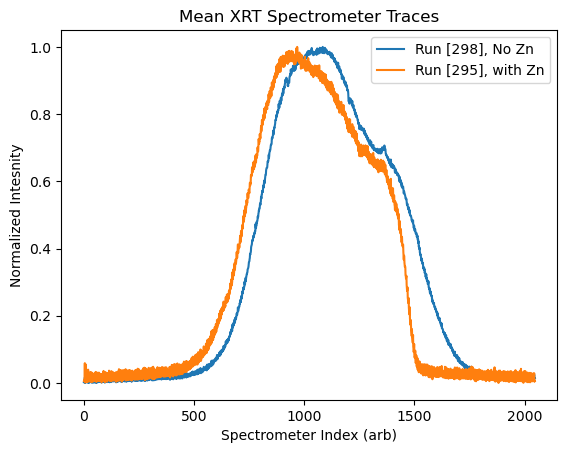

In [65]:
## Filter out the bad spectrometer shots and plot the average of the runs on top of each other
plt.figure()
specGood = spec[xrayOn][spec[xrayOn].sum(axis=1)>0]
specGoodMean = specGood.mean(axis=0)
specGoodMeanNorm = (specGoodMean - np.min(specGoodMean)) / (np.max(specGoodMean) - np.min(specGoodMean))
plt.plot(specGoodMeanNorm,label=f"Run {runNumbers}, No Zn")
specGoodZn = specZn[xrayOnZn][specZn[xrayOnZn].sum(axis=1)>0]
specGoodZnMean = specGoodZn.mean(axis=0)
specGoodZnMeanNorm = (specGoodZnMean - np.min(specGoodZnMean)) / (np.max(specGoodZnMean) - np.min(specGoodZnMean))
plt.plot(specGoodZnMeanNorm,label=f"Run {runNumbersZn}, with Zn")
plt.legend()
plt.title("Mean XRT Spectrometer Traces")
plt.ylabel("Normalized Intesnity")
plt.xlabel("Spectrometer Index (arb)")
plt.show()

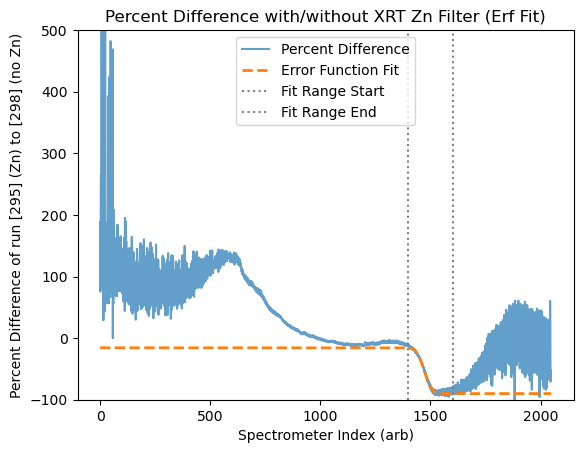

Center of erf: 1471.27


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf

# Normalize the spectra
specGoodMeanNorm = (specGoodMean - np.min(specGoodMean)) / (np.max(specGoodMean) - np.min(specGoodMean))
specGood2MeanNorm = (specGoodZnMean - np.min(specGoodZnMean)) / (np.max(specGoodZnMean) - np.min(specGoodZnMean))

# Compute percent difference while avoiding division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    pdiff = (specGoodZnMeanNorm - specGoodMeanNorm) / specGoodMeanNorm * 100
    pdiff = np.nan_to_num(pdiff, nan=0.0, posinf=0.0, neginf=0.0)  # Replace NaN and Inf with 0

# Define error function
def error_func(x, x0, width, amplitude, offset):
    return amplitude * erf((x - x0) / width) + offset

# Define spectrometer index range
x_vals = np.arange(len(pdiff))

######################################################## === Select range for fitting ===
fit_range = (1400, 1600)  # Adjust these values as needed
fit_mask = (x_vals >= fit_range[0]) & (x_vals <= fit_range[1])
################################################################

# Extract fitting subset
x_fit = x_vals[fit_mask]
pdiff_fit_range = pdiff[fit_mask]

# Initial parameter guesses
x0_guess = np.mean(fit_range)  # Center of transition
width_guess = (fit_range[1] - fit_range[0]) / 5  # Rough transition width
amplitude_guess = np.max(pdiff_fit_range) - np.min(pdiff_fit_range)  # Height of transition
offset_guess = np.mean(pdiff_fit_range)  # Baseline offset

# Fit error function within specified range
popt, _ = curve_fit(error_func, x_fit, pdiff_fit_range, 
                    p0=[x0_guess, width_guess, amplitude_guess, offset_guess])

# Generate fitted error function over full x_vals range
pdiff_fit = error_func(x_vals, *popt)

# Plot original data
plt.plot(pdiff, label="Percent Difference", alpha=0.7)

# Plot fitted error function
plt.plot(x_vals, pdiff_fit, label="Error Function Fit", linestyle="dashed", linewidth=2)

# Highlight the fit range
plt.axvline(fit_range[0], color="gray", linestyle="dotted", label="Fit Range Start")
plt.axvline(fit_range[1], color="gray", linestyle="dotted", label="Fit Range End")

# Labels and title
plt.ylabel(f"Percent Difference of run {runNumbersZn} (Zn) to {runNumbers} (no Zn)")
plt.xlabel("Spectrometer Index (arb)")
plt.title("Percent Difference with/without XRT Zn Filter (Erf Fit)")
plt.legend()

# Show plot
plt.ylim(-100,500)
plt.show()
print(f"Center of erf: {popt[0]:.2f}")

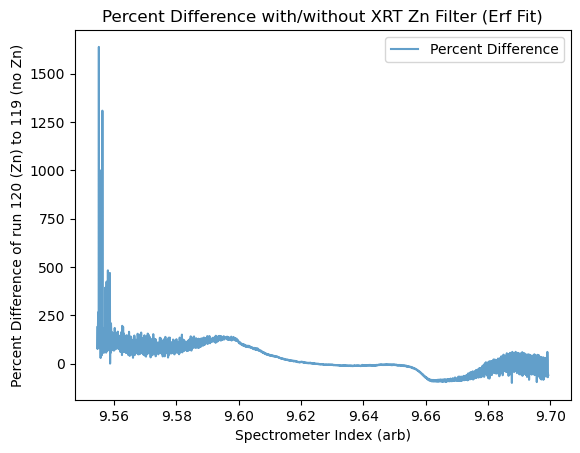

Center of erf: 1471.27


In [68]:
## Getting a calibration
m = 7.06567979135956e-05 # eV per pixel
ZnK = 9.6586 #keV
edge_center = popt[0]


# Generate pixel indices
pixels = np.arange(2048)

# Compute calibrated energy axis
energy_axis = m * (pixels - edge_center) + ZnK

# Plot original data
plt.plot(energy_axis,pdiff, label="Percent Difference", alpha=0.7)

# Highlight the fit range
#plt.axvline(fit_range[0], color="gray", linestyle="dotted", label="Fit Range Start")
#plt.axvline(fit_range[1], color="gray", linestyle="dotted", label="Fit Range End")

# Labels and title
plt.ylabel("Percent Difference of run 120 (Zn) to 119 (no Zn)")
plt.xlabel("Spectrometer Index (arb)")
plt.title("Percent Difference with/without XRT Zn Filter (Erf Fit)")
plt.legend()

# Show plot
plt.show()
print(f"Center of erf: {popt[0]:.2f}")

In [69]:
# Calibration Folder
np.save("ZnCalib/298-310.npy",energy_axis)